In [ ]:
# Check which version of Python is installed
!python --version

# Check which version of Jupyter Notebook you are using
!jupyter-notebook --version

Python 3.14.3
7.5.5


In [5]:
from datasets import load_dataset
import datasets
print(datasets.__version__)

reviews_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_All_Beauty",
    split="full",
    trust_remote_code=True
)

print("loaded")


2.21.0
loaded


In [44]:
import pandas as pd

sample_limit = 100
reviews_data = []

for i, item in enumerate(reviews_dataset):
    reviews_data.append(item)
    if i + 1 >= sample_limit:
        break

reviews_df = pd.DataFrame(reviews_data)

Items_To_Print = 10

print("done")
print(reviews_df.shape)
print(reviews_df.head())
for i, item in enumerate(reviews_df):
    if i + 1 > Items_To_Print:
        break
    print(item)

done
(100, 10)
   rating                                      title  \
0     5.0  Such a lovely scent but not overpowering.   
1     4.0     Works great but smells a little weird.   
2     5.0                                       Yes!   
3     1.0                          Synthetic feeling   
4     5.0                                         A+   

                                                text images        asin  \
0  This spray is really nice. It smells really go...     []  B00YQ6X8EO   
1  This product does what I need it to do, I just...     []  B081TJ8YS3   
2                          Smells good, feels great!     []  B07PNNCSP9   
3                                     Felt synthetic     []  B09JS339BZ   
4                                            Love it     []  B08BZ63GMJ   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B00YQ6X8EO  AGKHLEW2SOWHNMFQIJGBECAF7INQ  1588687728923             0   
1  B081TJ8YS3  AGKHLEW2SOWHNMFQIJGBECAF7INQ  

In [6]:
from datasets import load_dataset
import datasets
print(datasets.__version__)

metadata_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_All_Beauty",
    split="full",
    trust_remote_code=True
)

print("loaded")

2.21.0


Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

loaded


In [7]:
metadata_limit = 100
metadata_data = []

for i, item in enumerate(metadata_dataset):
    metadata_data.append(item)
    if i + 1 >= metadata_limit:
        break

item_metadata_df = pd.DataFrame(metadata_data)

print("done")
print(item_metadata_df.shape)
print(item_metadata_df.head())

done
(100, 16)
  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4             4.3              7   

                                            features  \
0                                                 []   
1                                                 []   
2                                                 []   
3                                                 []   
4  [Material: 304 Stainless Steel; Brass tip, Len...   

          

In [20]:
def get_product(product_id):
    try:
        product = item_metadata_df[item_metadata_df["parent_asin"] == product_id]
        if product.empty:
            return None
        return product.iloc[0]
    except Exception:
        return None
print("done")

done


In [19]:
reviews_df.info()
item_metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    str    
 2   text               100 non-null    str    
 3   images             100 non-null    object 
 4   asin               100 non-null    str    
 5   parent_asin        100 non-null    str    
 6   user_id            100 non-null    str    
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(1), str(5)
memory usage: 48.7+ KB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    100 non-null    str    
 1   title          

In [21]:
for name, df in [("reviews_df", reviews_df), ("item_metadata_df", item_metadata_df)]:
    print(name)
    print(list(df.columns))

reviews_df
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
item_metadata_df
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [22]:
print(reviews_df.dtypes)
print(item_metadata_df.dtypes)

rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price                  str
images              object
videos              object
store                  str
categories          object
details                str
parent_asin            str
bought_together     object
subtitle            object
author              object
dtype: object


In [23]:
reviews_df.info()
item_metadata_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    str    
 2   text               100 non-null    str    
 3   images             100 non-null    object 
 4   asin               100 non-null    str    
 5   parent_asin        100 non-null    str    
 6   user_id            100 non-null    str    
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(1), str(5)
memory usage: 48.7+ KB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    100 non-null    str    
 1   title          

In [24]:
average_rating_filter = 4.5

item_metadata_cleaned_df = item_metadata_df[["title", "average_rating", "price"]].copy()

item_metadata_cleaned_df["price"] = pd.to_numeric(
    item_metadata_cleaned_df["price"],
    errors="coerce"
)

top_products_df = item_metadata_cleaned_df[
    item_metadata_cleaned_df["title"].notna() &
    (item_metadata_cleaned_df["average_rating"] >= average_rating_filter) &
    item_metadata_cleaned_df["price"].notna()
].copy()

print(top_products_df.head())
print(top_products_df.shape)


                                                title  average_rating   price
32  Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...             5.0   22.49
33  Suavecito X Breast Cancer Solutions - Original...             4.8   11.99
55  Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...             5.0   24.84
57  Wholesale CASE of 10 - GOJO Supro Max Cherry H...             5.0  136.17
72  Amope PediMask Kit- 20 Minute Foot Mask to Rej...             4.5   12.00
(5, 3)


In [45]:
def calculate_percentage(part, whole):
    return part / whole

In [26]:
top_rated_titles = []

for title in top_products_df["title"]:
    top_rated_titles.append(title)

print(top_rated_titles)

['Enjoy VOLUMIZING ELIXIR, Style (with Sleek Steel Pin Tail Comb) (8.8 oz)', 'Suavecito X Breast Cancer Solutions - Original Hold Pomade', 'Armáf Täg Hïm Colognė For Men 3.4 oz Eau De Toilette Spray', 'Wholesale CASE of 10 - GOJO Supro Max Cherry Hand Cleaner-Supro Max Hand Cleaner, 2000l, Cherry', 'Amope PediMask Kit- 20 Minute Foot Mask to Rejuvenate and Soothe Your Feet with Blend of Moisturizers and Macadamia Oils for Baby Smooth Feet in Minutes (Pack of 3)']


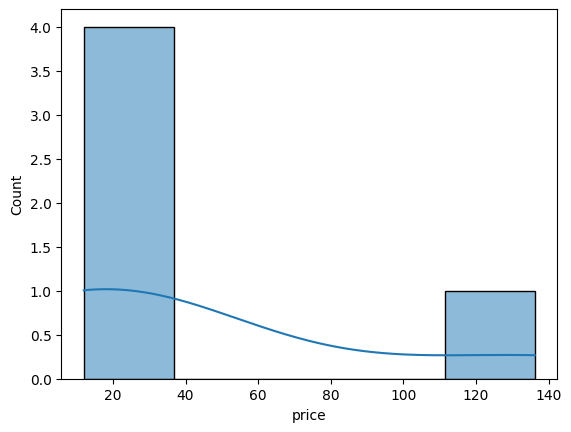

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=top_products_df, x="price", kde=True)
plt.show()

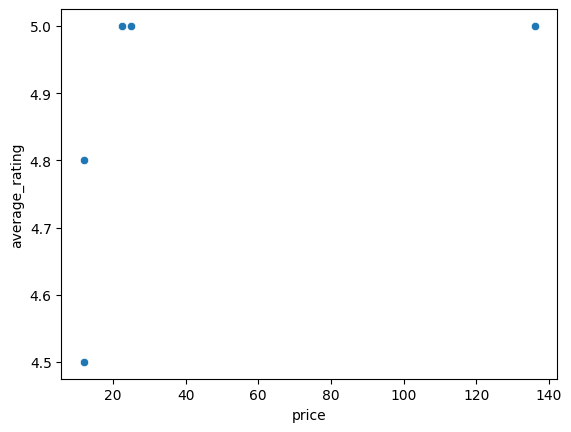

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=top_products_df, x="price", y="average_rating")
plt.show()

In [31]:
average_rating_filter = 4.7

top_products_df = item_metadata_cleaned_df[
    item_metadata_cleaned_df["title"].notna() &
    (item_metadata_cleaned_df["average_rating"] >= average_rating_filter) &
    item_metadata_cleaned_df["price"].notna()
].copy()

print(top_products_df.head())
print(top_products_df.shape)

                                                title  average_rating   price
32  Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...             5.0   22.49
33  Suavecito X Breast Cancer Solutions - Original...             4.8   11.99
55  Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...             5.0   24.84
57  Wholesale CASE of 10 - GOJO Supro Max Cherry H...             5.0  136.17
(4, 3)


In [32]:
top_products_df = top_products_df.sort_values(
    by="average_rating",
    ascending=False
)

print(top_products_df.head())

                                                title  average_rating   price
32  Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...             5.0   22.49
55  Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...             5.0   24.84
57  Wholesale CASE of 10 - GOJO Supro Max Cherry H...             5.0  136.17
33  Suavecito X Breast Cancer Solutions - Original...             4.8   11.99


                                                title  average_rating   price
32  Enjoy VOLUMIZING ELIXIR, Style (with Sleek Ste...             5.0   22.49
55  Armáf Täg Hïm Colognė For Men 3.4 oz Eau De To...             5.0   24.84
57  Wholesale CASE of 10 - GOJO Supro Max Cherry H...             5.0  136.17
33  Suavecito X Breast Cancer Solutions - Original...             4.8   11.99


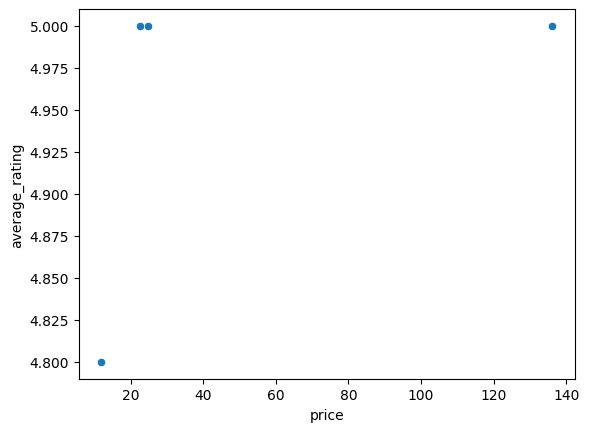

In [33]:
highly_rated_products_df_cutoff = 4.7

highly_rated_products_df = item_metadata_cleaned_df[
    item_metadata_cleaned_df["title"].notna() &
    (item_metadata_cleaned_df["average_rating"] >= highly_rated_products_df_cutoff) &
    item_metadata_cleaned_df["price"].notna()
].copy()

highly_rated_products_df = highly_rated_products_df.sort_values(
    by="average_rating",
    ascending=False
)

print(highly_rated_products_df)

sns.scatterplot(data=highly_rated_products_df, x="price", y="average_rating")
plt.show()

In [34]:
top_products_df.to_csv("top_products.csv", index=False)
top_products_df.to_parquet("top_products.parquet", index=False)